*@author: petra.boskovic*

In [12]:
#!pip install kagglehub librosa torch torchvision tqdm soundfile

# 1. IMPORTS

In [13]:
import os

import kagglehub
import numpy as np
import pandas as pd
import librosa
import librosa.display
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

Device: cuda


# 2. DATASET DOWNLOAD (via kagglehub)

In [14]:
print("Downloading / locating UrbanSound8K dataset via kagglehub...")
DATASET_DIR = kagglehub.dataset_download("chrisfilo/urbansound8k")
print("Dataset available at:", DATASET_DIR)

Using Colab cache for faster access to the 'urbansound8k' dataset.
Dataset available at: /kaggle/input/urbansound8k


In [30]:
CSV_PATH = os.path.join(DATASET_DIR, "UrbanSound8K.csv")
assert os.path.exists(CSV_PATH), f"Could not find CSV at: {CSV_PATH}"

In [31]:
# The folder layout differs between dataset copies/mounts: some have the fold1..fold10
# directories nested under an "audio" subfolder, others have them directly under the
# dataset root. Detect which one we actually have instead of hardcoding it.
if os.path.exists(os.path.join(DATASET_DIR, "audio", "fold1")):
    AUDIO_DIR = os.path.join(DATASET_DIR, "audio")
elif os.path.exists(os.path.join(DATASET_DIR, "fold1")):
    AUDIO_DIR = DATASET_DIR
else:
    raise FileNotFoundError(
        f"Could not locate fold1 under '{DATASET_DIR}' or '{DATASET_DIR}/audio'. "
        f"Contents found: {os.listdir(DATASET_DIR)}"
    )
print("Audio directory resolved to:", AUDIO_DIR)

Audio directory resolved to: /kaggle/input/urbansound8k


In [17]:
metadata = pd.read_csv(CSV_PATH)
metadata.head()

,slice_file_name,fsID,start,end,salience,fold,classID,class
0,100032-3-0-0.wav,100032,0.0,0.317551,1,5,3,dog_bark
1,100263-2-0-117.wav,100263,58.5,62.500000,1,5,2,children_playing
2,100263-2-0-121.wav,100263,60.5,64.500000,1,5,2,children_playing
3,100263-2-0-126.wav,100263,63.0,67.000000,1,5,2,children_playing
4,100263-2-0-137.wav,100263,68.5,72.500000,1,5,2,children_playing


# 3. EXPLORATORY DATA ANALYSIS (EDA)

In [18]:
print("Number of samples:", len(metadata))
print("Number of classes:", metadata["class"].nunique())
print("Folds present:", sorted(metadata["fold"].unique()))

Number of samples: 8732
Number of classes: 10
Folds present: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10)]


In [20]:
class_map = metadata[["classID", "class"]].drop_duplicates().sort_values("classID")
print(class_map)

     classID             class
22         0   air_conditioner
9          1          car_horn
1          2  children_playing
0          3          dog_bark
196        4          drilling
122        5     engine_idling
106        6          gun_shot
171        7        jackhammer
114        8             siren
94         9      street_music


In [21]:
print("Missing values per column:")
print(metadata.isna().sum())
print("Duplicated rows:", metadata.duplicated().sum())

Missing values per column:
slice_file_name    0
fsID               0
start              0
end                0
salience           0
fold               0
classID            0
class              0
dtype: int64
Duplicated rows: 0


/tmp/ipykernel_1068/1562542974.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=metadata, y="class", order=order, palette="viridis")


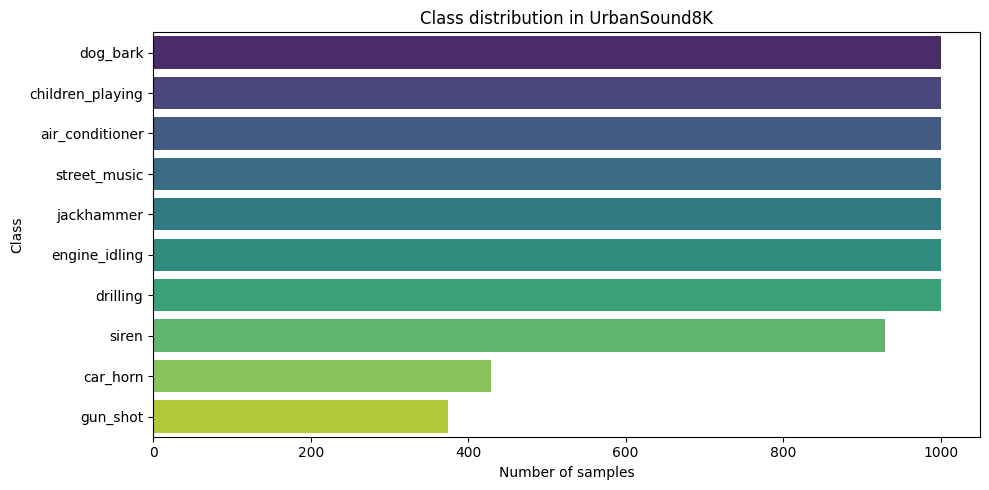

In [23]:
plt.figure(figsize=(10, 5))
order = metadata["class"].value_counts().index
sns.countplot(data=metadata, y="class", order=order, palette="viridis")
plt.title("Class distribution in UrbanSound8K")
plt.xlabel("Number of samples")
plt.ylabel("Class")
plt.tight_layout()
plt.show()

/tmp/ipykernel_1068/1436279954.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=metadata, x="fold", palette="mako")


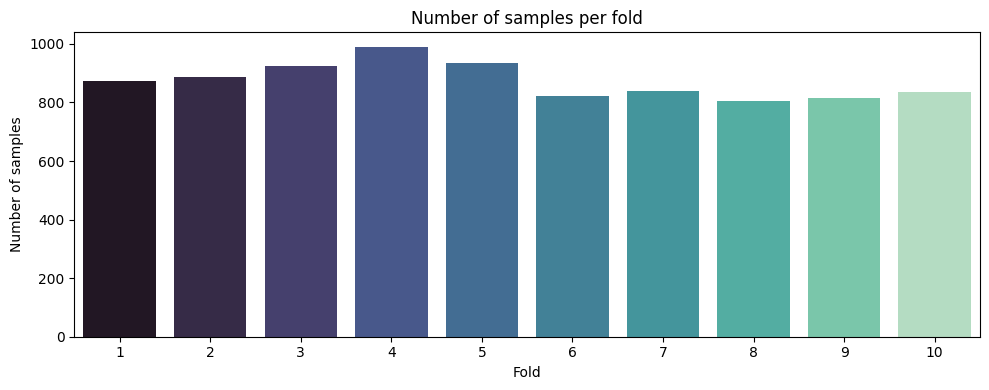

In [25]:
plt.figure(figsize=(10, 4))
sns.countplot(data=metadata, x="fold", palette="mako")
plt.title("Number of samples per fold")
plt.xlabel("Fold")
plt.ylabel("Number of samples")
plt.tight_layout()
plt.show()

In [26]:
durations = metadata["end"] - metadata["start"]
print("Clip duration stats (seconds):")
print(durations.describe())

Clip duration stats (seconds):
count    8732.000000
mean        3.607904
std         0.973570
min         0.054517
25%         4.000000
50%         4.000000
75%         4.000000
max         4.000000
dtype: float64


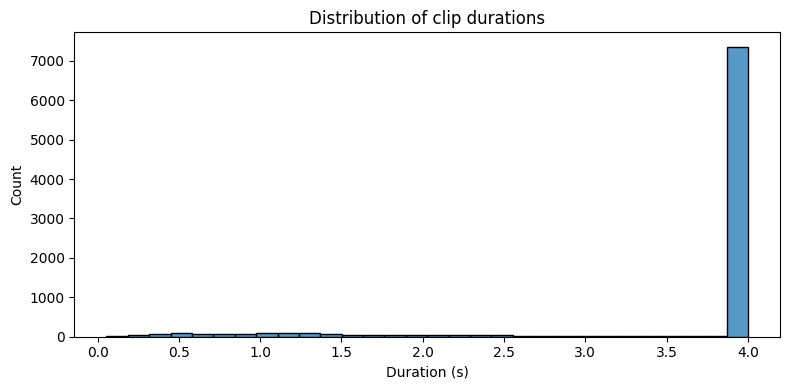

In [27]:
plt.figure(figsize=(8, 4))
sns.histplot(durations, bins=30)
plt.title("Distribution of clip durations")
plt.xlabel("Duration (s)")
plt.tight_layout()
plt.show()

In [28]:
sample_per_class = metadata.groupby("class").first().reset_index()

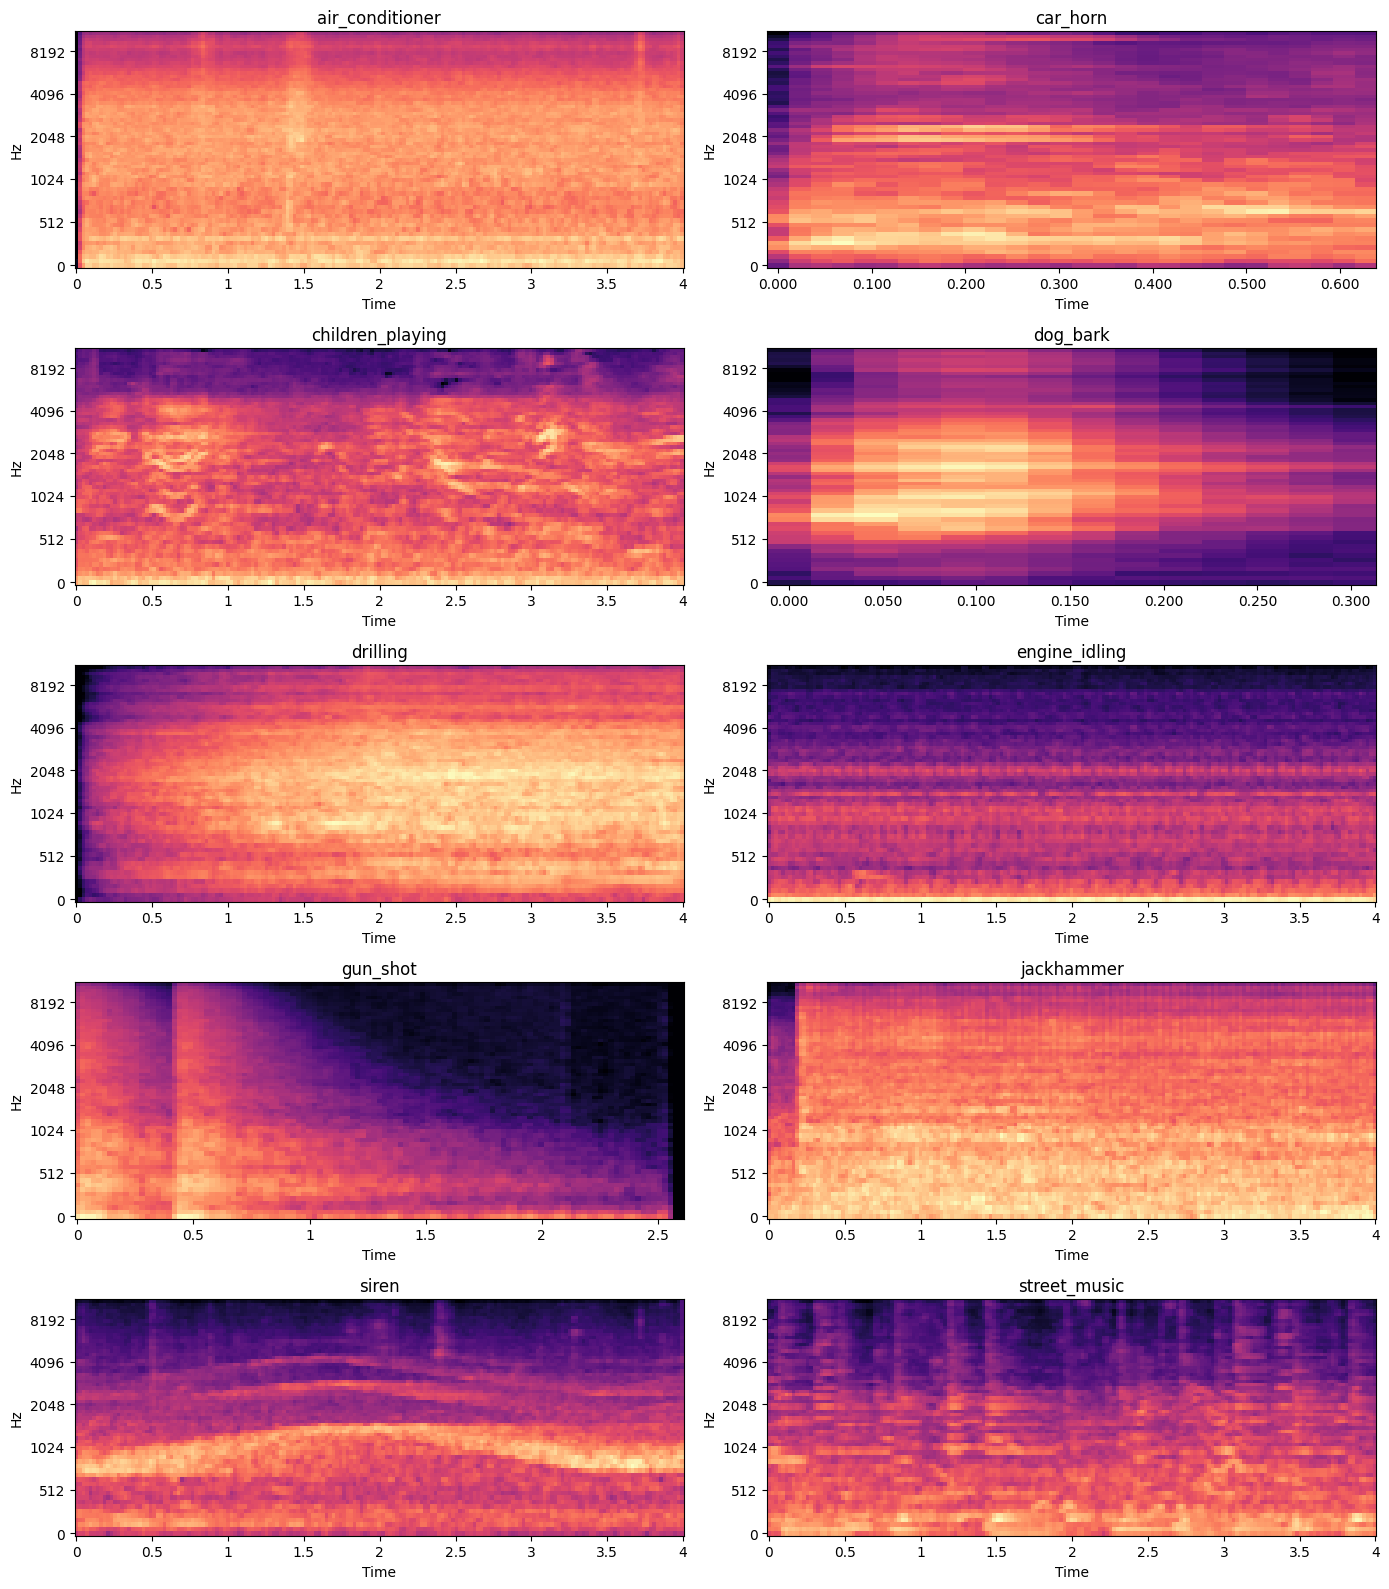

In [32]:
fig, axes = plt.subplots(5, 2, figsize=(14, 16))
axes = axes.flatten()
for i, row in sample_per_class.iterrows():
    path = os.path.join(AUDIO_DIR, f"fold{row['fold']}", row["slice_file_name"])
    try:
        y, sr = librosa.load(path, sr=22050)
        mel = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=64)
        mel_db = librosa.power_to_db(mel, ref=np.max)
        librosa.display.specshow(mel_db, sr=sr, x_axis="time", y_axis="mel", ax=axes[i])
        axes[i].set_title(row["class"])
    except Exception as e:
        print(f"Could not load sample for '{row['class']}' ({path}): {e}")
        axes[i].set_title(f"{row['class']} (load failed)")
plt.tight_layout()
plt.show()

# 4. FEATURE ENGINEERING